<a href="https://colab.research.google.com/github/aayushisharma9576/synent-Task-5-To-Do-List-Web-Ayushi/blob/main/student_placeemt_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [7]:
#load daatset
df = pd.read_csv("placeemt.csv")



In [8]:
#view daatset
print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())



FIRST 5 ROWS
   CGPA   IQ  Skills  Internships  Aptitude  Placed
0   8.5  120       7            2        85       1
1   7.2  110       6            1        70       1
2   6.0   90       4            0        45       0
3   9.1  130       9            3        92       1
4   5.8   85       3            0        40       0

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CGPA         40 non-null     float64
 1   IQ           40 non-null     int64  
 2   Skills       40 non-null     int64  
 3   Internships  40 non-null     int64  
 4   Aptitude     40 non-null     int64  
 5   Placed       40 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 2.0 KB
None

STATISTICAL SUMMARY
           CGPA          IQ     Skills  Internships   Aptitude     Placed
count  40.00000   40.000000  40.000000    40.000000  40.000000  40.000000

In [9]:
#check missing values
print("\nMISSING VALUES")
print(df.isnull().sum())

# Fill missing values if present
df.fillna(df.mean(numeric_only=True), inplace=True)



MISSING VALUES
CGPA           0
IQ             0
Skills         0
Internships    0
Aptitude       0
Placed         0
dtype: int64


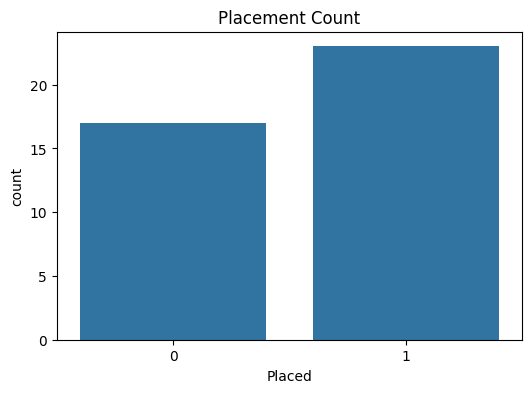

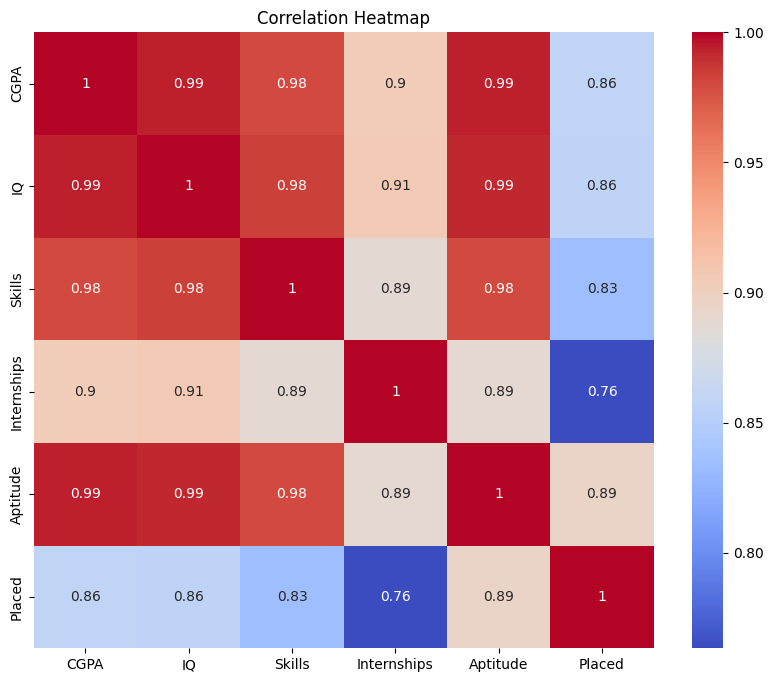

In [10]:
#daat visualization

# Placement Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='Placed', data=df)
plt.title("Placement Count")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



In [11]:
#split input and output
# Input Features
X = df.drop('Placed', axis=1)

# Target Variable
y = df['Placed']

print("\nINPUT FEATURES")
print(X.head())

print("\nTARGET VARIABLE")
print(y.head())


INPUT FEATURES
   CGPA   IQ  Skills  Internships  Aptitude
0   8.5  120       7            2        85
1   7.2  110       6            1        70
2   6.0   90       4            0        45
3   9.1  130       9            3        92
4   5.8   85       3            0        40

TARGET VARIABLE
0    1
1    1
2    0
3    1
4    0
Name: Placed, dtype: int64


In [12]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAINING DATA SIZE:", X_train.shape)
print("TESTING DATA SIZE:", X_test.shape)




TRAINING DATA SIZE: (32, 5)
TESTING DATA SIZE: (8, 5)


In [13]:
#feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
#train machine learning model
# Instantiate the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [18]:
#make prediction
y_pred = model.predict(X_test)

print("\nPREDICTED VALUES")
print(y_pred)




PREDICTED VALUES
[1 1 0 0 0 1 1 1]


In [19]:
#model evaluation
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY")
print("Accuracy:", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print(cm)

# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))




MODEL ACCURACY
Accuracy: 100.0 %

CONFUSION MATRIX
[[3 0]
 [0 5]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [20]:
#test with coustom input
# Example:
# [CGPA, IQ, Skills, Internships, Aptitude]

new_student = [[8.5, 120, 7, 2, 85]]

# Scale Input
new_student = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student)

print("\nCUSTOM STUDENT PREDICTION")

if prediction[0] == 1:
    print("Student Will Be Placed")
else:
    print("Student Will NOT Be Placed")


CUSTOM STUDENT PREDICTION
Student Will Be Placed


In [21]:
#save model
import pickle

pickle.dump(model, open('placement_model.pkl', 'wb'))

print("\nMODEL SAVED SUCCESSFULLY")



MODEL SAVED SUCCESSFULLY


In [22]:
#load model again
loaded_model = pickle.load(open('placement_model.pkl', 'rb'))

print("\nMODEL LOADED SUCCESSFULLY")



MODEL LOADED SUCCESSFULLY


In [23]:
#predict again using loaded model
prediction2 = loaded_model.predict(new_student)

print("\nPREDICTION USING LOADED MODEL")

if prediction2[0] == 1:
    print("Placed")
else:
    print("Not Placed")



PREDICTION USING LOADED MODEL
Placed
